In [ ]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, chi2_contingency
import warnings
from datetime import datetime, date

from src.features import engineer_features

warnings.filterwarnings("ignore")

raw_df = pd.read_csv(r"../data/fraudTrain.csv")
df = engineer_features(raw_df)

display(df.head())
print(
    df.columns
)  # Note: removed parentheses from .columns, as it is a property, not a function!

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,historical_mean_amt,historical_std_amt,z_score,hour,day_string,is_weekend,transaction_month,night_trans,amt_log,high_value_transaction
0,1017,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,...,NaN,NaN,0.000000,12,Tuesday,0,January,False,2.112635,0
1,2724,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,...,7.270,NaN,0.000000,8,Wednesday,0,January,False,3.987872,0
2,2726,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,...,30.105,32.293567,1.609454,8,Wednesday,0,January,False,4.419804,0
3,2882,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,34.79,Mary,Diaz,F,9886 Anita Drive,...,47.430,37.708144,-0.335206,12,Wednesday,0,January,False,3.577669,0
4,2907,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,27.18,Mary,Diaz,F,9886 Anita Drive,...,44.270,31.430534,-0.543739,13,Wednesday,0,January,False,3.338613,0


Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'customer_id', 'age', 'distance',
       'amt_percentile', 'time_since_last_transaction', 'is_first_transaction',
       'log_time_since_last_transaction', 'transactions_last_1h',
       'transactions_last_6h', 'transactions_last_24h', 'historical_mean_amt',
       'historical_std_amt', 'z_score', 'hour', 'day_string', 'is_weekend',
       'transaction_month', 'night_trans', 'amt_log',
       'high_value_transaction'],
      dtype='object')


In [3]:
display(df.loc[df['state'] == 'DE'])

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,historical_mean_amt,historical_std_amt,z_score,hour,day_string,is_weekend,transaction_month,night_trans,amt_log,high_value_transaction
1125982,233631,2019-04-28 00:41:37,6011826317034777,fraud_Schamberger-O'Keefe,grocery_pos,294.91,Christine,Johnson,F,9612 Robert Light Apt. 340,...,NaN,NaN,0.000000,0,Sunday,1,April,True,5.690055,1
1125983,233744,2019-04-28 01:49:28,6011826317034777,fraud_Kuphal-Predovic,misc_net,868.29,Christine,Johnson,F,9612 Robert Light Apt. 340,...,294.910000,NaN,0.000000,1,Sunday,1,April,True,6.767677,1
1125984,233826,2019-04-28 02:33:09,6011826317034777,fraud_Goodwin-Nitzsche,grocery_pos,280.26,Christine,Johnson,F,9612 Robert Light Apt. 340,...,581.600000,405.440886,-0.743240,2,Sunday,1,April,True,5.639280,1
1125985,234625,2019-04-28 10:24:34,6011826317034777,"fraud_Huel, Hammes and Witting",grocery_pos,296.25,Christine,Johnson,F,9612 Robert Light Apt. 340,...,481.153333,335.350197,-0.551374,10,Sunday,1,April,False,5.694574,1
1125986,236522,2019-04-28 23:03:24,6011826317034777,fraud_Waters-Cruickshank,health_fitness,20.58,Christine,Johnson,F,9612 Robert Light Apt. 340,...,434.927500,288.999101,-1.433733,23,Sunday,1,April,True,3.071767,0
1125987,236643,2019-04-28 23:41:43,6011826317034777,fraud_Cormier LLC,shopping_net,1012.77,Christine,Johnson,F,9612 Robert Light Apt. 340,...,352.058000,311.411513,2.121669,23,Sunday,1,April,True,6.921431,1
1125988,237095,2019-04-29 03:29:41,6011826317034777,fraud_Ruecker Group,misc_net,885.96,Christine,Johnson,F,9612 Robert Light Apt. 340,...,462.176667,387.734998,1.092972,3,Monday,0,April,True,6.787800,1
1125989,237740,2019-04-29 10:13:47,6011826317034777,fraud_Smitham-Schiller,grocery_net,10.93,Christine,Johnson,F,9612 Robert Light Apt. 340,...,522.717143,388.507489,-1.317316,10,Monday,0,April,False,2.479056,0
1125990,239854,2019-04-29 23:51:22,6011826317034777,"fraud_Baumbach, Feeney and Morar",shopping_net,960.49,Christine,Johnson,F,9612 Robert Light Apt. 340,...,458.743750,402.636620,1.246152,23,Monday,0,April,True,6.868484,1


2026-08-19
52.74254535639231
21
102
  age_group  total_transactions  fraud_rate
0     18-24               13430    0.004468
1     25-34              168073    0.006158
2     35-44              304161    0.004524
3     45-54              294847    0.004385
4     55-64              207810    0.006833
5       65+              301744    0.007576


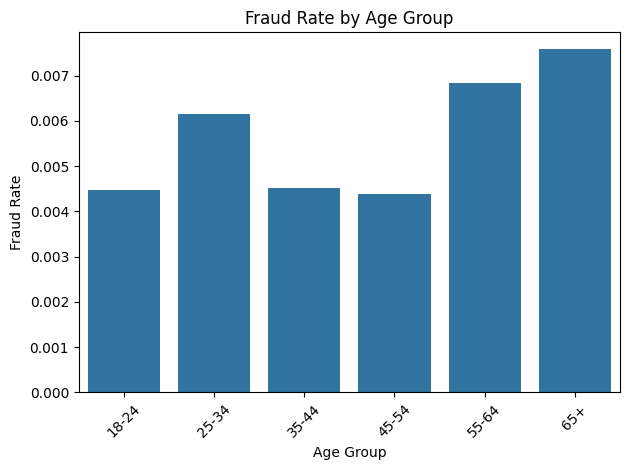

In [4]:
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

today = date.today()
df["dob"] = pd.to_datetime(df["dob"])
print(today)


df["age"] = (pd.Timestamp.now().year) - pd.to_datetime(df["dob"]).dt.year
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)
print(df['age'].mean())
print(df["age"].min())
print(df["age"].max())
fraud_summary = (
    df.groupby("age_group", observed=False)
    .agg(total_transactions=("is_fraud", "count"), fraud_rate=("is_fraud", "mean"))
    .reset_index()
)

print(fraud_summary)
fraud_data = df.groupby("age_group")["is_fraud"].agg(["sum", "count"])
fraud_data["fraud_rate"] = fraud_data["sum"] / fraud_data["count"]

sns.barplot(
    data=fraud_data.reset_index(), x="age_group", y="fraud_rate"
)
plt.title("Fraud Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
print(df['amt'].describe().round(2))
percentile_95 = np.percentile(df['amt'],95)
print(percentile_95)

count    1296675.00
mean          70.35
std          160.32
min            1.00
25%            9.65
50%           47.52
75%           83.14
max        28948.90
Name: amt, dtype: float64
196.31


  gender  total_transactions  fraud_rate
0      F              709863    0.005262
1      M              586812    0.006426


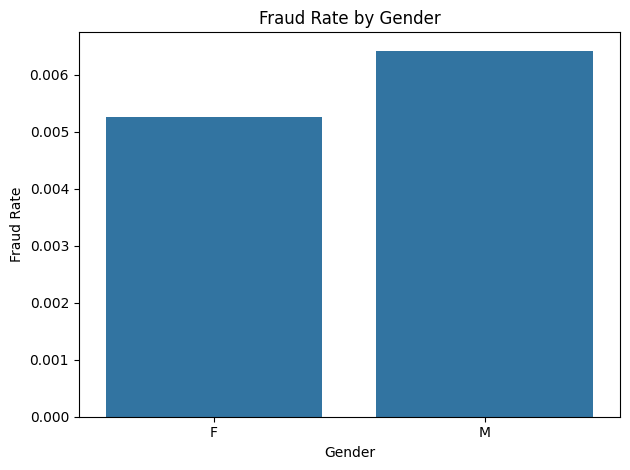

<Figure size 640x480 with 0 Axes>

gender
F    709863
M    586812
Name: count, dtype: int64


In [6]:
fraud_summary = (
    df.groupby("gender", observed=False)
    .agg(total_transactions=("is_fraud", "count"), fraud_rate=("is_fraud", "mean"))
    .reset_index()
)
print(fraud_summary)
gender_fraud = df.groupby("gender")["is_fraud"].agg(["sum", "count"])
gender_fraud["fraud_rate"] = gender_fraud["sum"] / gender_fraud["count"]


sns.barplot(
    data=gender_fraud.reset_index(), x="gender", y="fraud_rate"
)
plt.title("Fraud Rate by Gender")  
plt.xlabel("Gender")  # Fixed label
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.savefig("fraud_by_gender.png", dpi=300)
plt.show()

plt.tight_layout()
plt.show()
counts = df["gender"].value_counts()
print(counts)

location_type
Rural       993873
Urban       178874
Suburban    123928
Name: count, dtype: int64
                sum   count  fraud_rate
location_type                          
Rural          5711  993873    0.005746
Suburban        619  123928    0.004995
Urban          1176  178874    0.006574


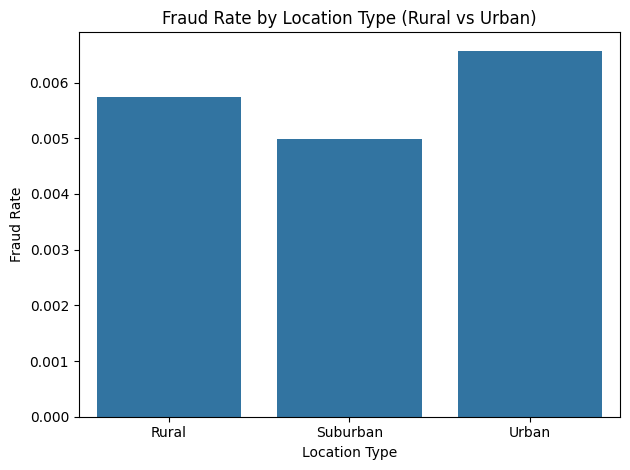

In [7]:

df["location_type"] = pd.cut(
    df["city_pop"],
    bins=[0, 25000, 100000, float("inf")],
    labels=["Rural", "Suburban", "Urban"],
)

print(df["location_type"].value_counts())

location_fraud = df.groupby("location_type")["is_fraud"].agg(["sum", "count"])
location_fraud["fraud_rate"] = location_fraud["sum"] / location_fraud["count"]

print(location_fraud)

sns.barplot(
    data=location_fraud.reset_index(),
    x="location_type",
    y="fraud_rate",
)
plt.title("Fraud Rate by Location Type (Rural vs Urban)")
plt.xlabel("Location Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.savefig("fraud_by_location.png", dpi=300)
plt.show()

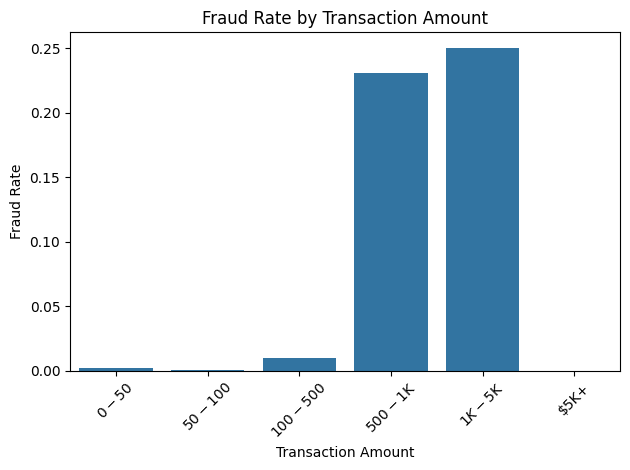

            count   sum  fraud_rate
amt                                
$0-$50     672299  1607    0.002390
$50-$100   389483    45    0.000116
$100-$500  219262  2206    0.010061
$500-$1K    11695  2699    0.230782
$1K-$5K      3800   949    0.249737
$5K+          136     0    0.000000


In [8]:

amount_brackets = pd.cut(
    df["amt"],
    bins=[0, 50, 100, 500, 1000, 5000, 30000],
    labels=["$0-$50", "$50-$100", "$100-$500", "$500-$1K", "$1K-$5K", "$5K+"],
)

fraud_by_amount = df.groupby(amount_brackets)["is_fraud"].agg(["count", "sum", "mean"])
fraud_by_amount.columns = ["total_transactions", "fraud_count", "fraud_rate"]

amount_brackets = pd.cut(
    df["amt"],
    bins=[0, 50, 100, 500, 1000, 5000, 30000],
    labels=["$0-$50", "$50-$100", "$100-$500", "$500-$1K", "$1K-$5K", "$5K+"],
)


fraud_by_amount = df.groupby(amount_brackets)["is_fraud"].agg(["count", "sum"])
fraud_by_amount["fraud_rate"] = fraud_by_amount["sum"] / fraud_by_amount["count"]

sns.barplot(
    data=fraud_by_amount.reset_index(), x="amt", y="fraud_rate"
)
plt.title("Fraud Rate by Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fraud_by_amount.png", dpi=300)
plt.show()

print(fraud_by_amount)

                 sum   count  fraud_rate
category                                
entertainment    233   94014    0.002478
food_dining      151   91461    0.001651
gas_transport    618  131659    0.004694
grocery_net      134   45452    0.002948
grocery_pos     1743  123638    0.014098
health_fitness   133   85879    0.001549
home             198  123115    0.001608
kids_pets        239  113035    0.002114
misc_net         915   63287    0.014458
misc_pos         250   79655    0.003139
personal_care    220   90758    0.002424
shopping_net    1713   97543    0.017561
shopping_pos     843  116672    0.007225
travel           116   40507    0.002864


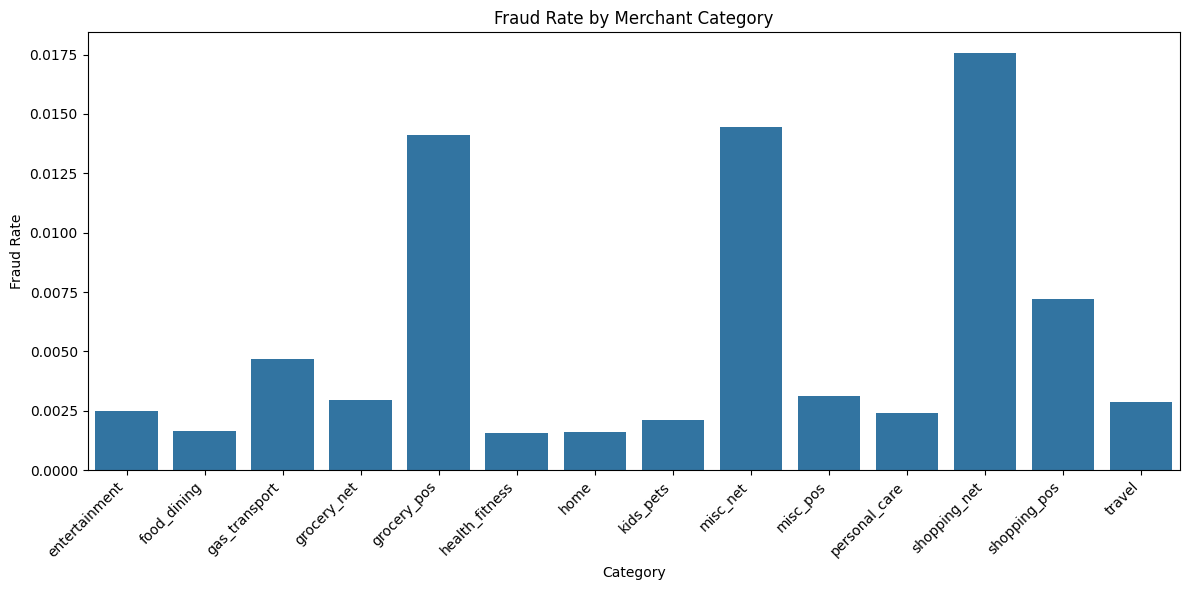

In [9]:

category_fraud = df.groupby("category")["is_fraud"].agg(["sum", "count"])
category_fraud["fraud_rate"] = category_fraud["sum"] / category_fraud["count"]
print(category_fraud)


fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=category_fraud.reset_index(), x="category", y="fraud_rate", ax=ax)

# 4. Final formatting and saving
plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45, ha="right")  # 'ha=right' aligns rotated labels cleanly
plt.tight_layout()
plt.savefig("fraud_by_merchant_category.png", dpi=300)
plt.show()